Ojective:
To build a convolutinal Auto encoder(CAE) that compress facial images into a lower dimensional latend represents and reconstructs them wit  minimal loss of information

purpose:
A convolutional autoencoder is an unsupervised deep learning model used for
Image compresion image recognition feature extraction dimensinality Reduction
The encoder learns a compressed representation (latent space) while the decoder reconstructs the original image from this compressed representation

In [1]:
  #libraries
import os
import shutil
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import UpSampling2D
from tensorflow.keras.layers import Input
from tensorflow.keras.models import Model

In [2]:
!pip install -q kaggle

In [3]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"diwakardiwakar123","key":"0d4db80c412dd9c09055282af239aed0"}'}

In [4]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [5]:
!kaggle datasets download -d jessicali9530/celeba-dataset

Dataset URL: https://www.kaggle.com/datasets/jessicali9530/celeba-dataset
License(s): other
100% 1.33G/1.33G [01:05<00:00, 21.9MB/s]



In [6]:
!unzip -q celeba-dataset.zip

In [7]:
import os
import shutil
source_folder= os.path.join("img_align_celeba","img_align_celeba")
destination_folder= "celeba_small/faces"
os.makedirs(destination_folder,exist_ok=True)
images=sorted(os.listdir(source_folder))[:5000]
for image in images:
  shutil.copy(
      os.path.join(source_folder,image),
      destination_folder)

print("Copied",len(images),"images")

Copied 5000 images


In [8]:
IMAGE_SIZE=(64,64)
BATCH_SIZE=32

In [9]:
datagen=ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
    )

In [10]:
train_generator=datagen.flow_from_directory(
    "celeba_small",
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="input",
    subset="training"
)

Found 4000 images belonging to 1 classes.


In [11]:
validation_generator=datagen.flow_from_directory(
    "celeba_small",
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="input",
    subset="validation"
)

Found 1000 images belonging to 1 classes.


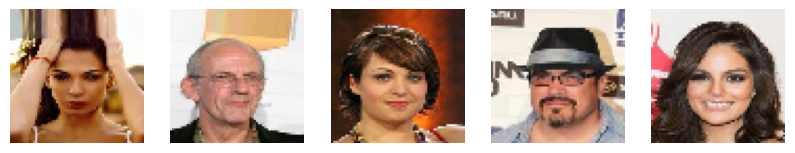

In [12]:
images,_ = next(train_generator)
plt.figure(figsize=(10,5))
for i in range(5):
  plt.subplot(1,5,i+1)
  plt.imshow(images[i])
  plt.axis("off")
plt.show()

In [13]:
#encoder
input_img=Input(shape=(64,64,3))
x=Conv2D(
    32,
    (3,3),
    activation="relu",
    padding="same"
    )(input_img)
x=MaxPooling2D((2,2),padding="same")(x)

In [14]:
input_img=Input(shape=(64,64,3))
x=Conv2D(32,(3,3),activation="relu",padding="same")(input_img)
x=MaxPooling2D((2,2),padding="same")(x)
x=Conv2D(64,(3,3),activation="relu",padding="same")(x)
encoded=MaxPooling2D((2,2),padding="same")(x)

In [15]:
#decoder
x = Conv2D(
    64,
    (3,3),
    activation="relu",
    padding="same"
)(encoded)
x=UpSampling2D((2,2))(x)
x=Conv2D(
    32,
    (3,3),
    activation="relu",
    padding="same"

)(x)
x = UpSampling2D((2,2))(x)
decoded=Conv2D(
    3,
     (3,3),
    padding="same"
)(x)

In [16]:
autoencoder = Model(input_img, decoded)
autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 64, 64, 3)      │           867 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 75,651 (295.51 KB)

 Trainable params: 75,651 (295.51 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
autoencoder.compile(optimizer='adam', loss='mse')
history  = autoencoder.fit(
    train_generator,
    epochs=10,
    validation_data=validation_generator
)

Epoch 1/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 11s 43ms/step - loss: 0.0248 - val_loss: 0.0081
Epoch 2/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 41ms/step - loss: 0.0071 - val_loss: 0.0063
Epoch 3/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - loss: 0.0060 - val_loss: 0.0055
Epoch 4/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - loss: 0.0056 - val_loss: 0.0052
Epoch 5/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step - loss: 0.0052 - val_loss: 0.0049
Epoch 6/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - loss: 0.0050 - val_loss: 0.0048
Epoch 7/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - loss: 0.0047 - val_loss: 0.0045
Epoch 8/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - loss: 0.0047 - val_loss: 0.0043
Epoch 9/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - loss: 0.0045 - val_loss: 0.0042
Epoch 10/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - loss: 0.0043 - val_loss: 0.0041


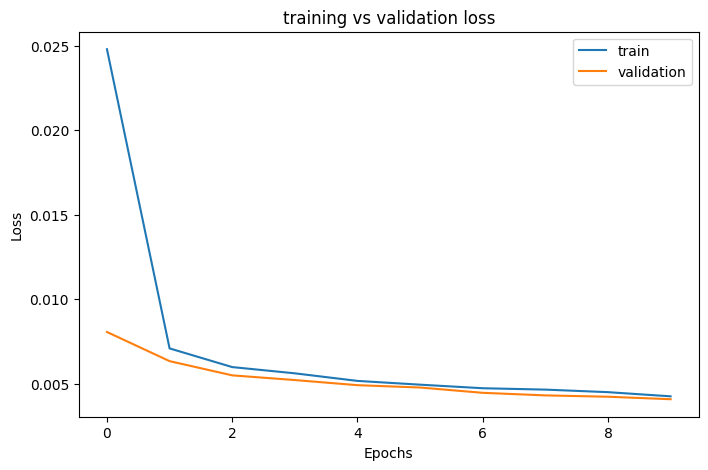

In [18]:
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title("training vs validation loss")
plt.legend(['train','validation'])
plt.show()

In [19]:
#from PIL import Image
#reconstruct Images
image,_ = next(validation_generator)

reconstructed = autoencoder.predict(images)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 414ms/step


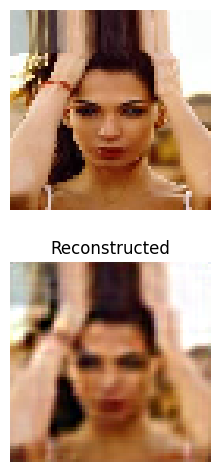

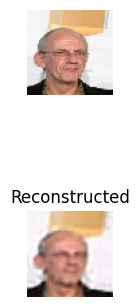

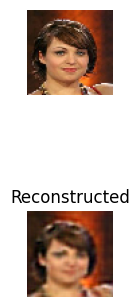

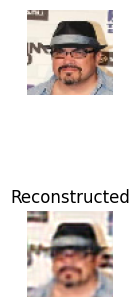

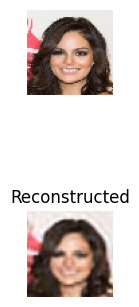

In [20]:
#display results
n = 5
plt.figure(figsize=(15,6))
for i in range(n):
  plt.subplot(2,n,i+1)
  plt.imshow(images[i])
  plt.axis("off")
  plt.subplot(2,n,i+1+n)
  plt.imshow(reconstructed[i])
  plt.title("Reconstructed")
  plt.axis("off")
  plt.show()